# CfD Hedge Model — Part 2: Weather Risk
Models how temperature and wind affect electricity demand/supply,
and how this changes hedge effectiveness. Includes Monte Carlo simulation.

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
from dataclasses import dataclass
from typing import List

plt.rcParams['figure.dpi'] = 120

@dataclass
class CfDPosition:
    name: str
    strike_price: float          
    volume_mwh_per_month: float  
    direction: str               
    months_remaining: int = 180  

    def monthly_settlement(self, reference_price: float) -> float:
        """Calculate CfD settlement for ONE month only."""
        diff = reference_price - self.strike_price
        payout = diff * self.volume_mwh_per_month
        return payout if self.direction == 'long' else -payout
    
    def settlement(self, reference_price: float) -> float:
        """Alias for monthly_settlement (backward compatibility)."""
        return self.monthly_settlement(reference_price)
    
    def total_remaining_value(self, reference_price: float, discount_rate: float = 0.05) -> float:
        """Calculate present value of ALL remaining months (15 years)."""
        monthly_discount = (1 + discount_rate) ** (1/12) - 1
        total_value = 0
        for month in range(self.months_remaining):
            discount_factor = 1 / ((1 + monthly_discount) ** month)
            monthly_cash = self.monthly_settlement(reference_price)
            total_value += monthly_cash * discount_factor
        return total_value

# Portfolio with MONTHLY volumes (not total volumes)
portfolio = [
    CfDPosition('Wind CfD A',     strike_price=55.0, volume_mwh_per_month=5000, direction='long',  months_remaining=180),  # 15 years
    CfDPosition('Wind CfD B',     strike_price=62.0, volume_mwh_per_month=3000, direction='long',  months_remaining=72),    # 6 years left
    CfDPosition('Solar CfD',      strike_price=48.0, volume_mwh_per_month=2000, direction='long',  months_remaining=180),  # 15 years
    CfDPosition('Gas hedge short',strike_price=80.0, volume_mwh_per_month=4000, direction='short', months_remaining=12),    # 1 year left
]

BASE_LOAD_MWH_PER_MONTH = 16000   
BASE_REF_PRICE = 70.0             

print('Setup complete.')
print(f'Portfolio: {len(portfolio)} positions')
print(f'Total hedged volume per month: {sum(p.volume_mwh_per_month for p in portfolio):,.0f} MWh')
print(f'Hedge ratio: {sum(p.volume_mwh_per_month for p in portfolio)/BASE_LOAD_MWH_PER_MONTH:.1%}')

Setup complete (UPDATED: monthly volumes, 15-year tenors).
Portfolio: 4 positions
Total hedged volume per month: 14,000 MWh
Hedge ratio: 87.5%


In [8]:
# Weather-to-demand model
# Energy retailers face weather risk because demand and renewable output
# both vary with temperature and wind. This is one of the largest risks
# in the business 
#
# HDD (Heating Degree Days): proxy for heating demand
# Each degree below 15.5°C adds proportional electricity demand.

BASE_TEMP_C = 10.0                    # average UK winter temperature
HDD_BASE    = 15.5                    # standard base temperature for HDD calc
DEMAND_SENSITIVITY = 80               # MWh extra demand per degree colder

def temperature_to_demand(temp_c: float, base_load: float = BASE_LOAD_MWH_PER_MONTH) -> float:
    """Estimate total electricity demand from temperature."""
    hdd = max(HDD_BASE - temp_c, 0)
    base_hdd = max(HDD_BASE - BASE_TEMP_C, 0)
    demand_delta = (hdd - base_hdd) * DEMAND_SENSITIVITY
    return base_load + demand_delta

# Wind generation model: output as % of installed capacity
WIND_CAPACITY_MWH = 6000              # installed wind in portfolio
BASE_WIND_CF = 0.35                   # baseline capacity factor (35%)

def wind_speed_to_generation(wind_cf: float) -> float:
    """Convert capacity factor to MWh generation."""
    return WIND_CAPACITY_MWH * np.clip(wind_cf, 0, 1)

# Price model: price rises when demand is high or wind is low
PRICE_SENSITIVITY_DEMAND = 0.003      # £/MWh per extra MWh demand
PRICE_SENSITIVITY_WIND   = -0.005     # £/MWh per extra MWh wind

def weather_to_price(temp_c: float, wind_cf: float) -> float:
    """Simplified merit-order price model."""
    demand = temperature_to_demand(temp_c)
    wind_gen = wind_speed_to_generation(wind_cf)
    demand_effect = (demand - BASE_LOAD_MWH_PER_MONTH) * PRICE_SENSITIVITY_DEMAND
    wind_effect = (wind_gen - BASE_WIND_CF * WIND_CAPACITY_MWH) * PRICE_SENSITIVITY_WIND
    price = BASE_REF_PRICE + demand_effect + wind_effect
    return round(price, 2)

# sanity check
scenarios = {
    'Cold, low wind  (worst case)': (-5, 0.10),
    'Average                      ': (10, 0.35),
    'Mild, windy     (best case) ': (15, 0.55),
}
print(f'{"Scenario":<35} {"Temp":>6} {"Wind CF":>8} {"Demand MWh":>12} {"Price £/MWh":>12}')
print('-' * 75)
for name, (temp, wcf) in scenarios.items():
    d = temperature_to_demand(temp)
    p = weather_to_price(temp, wcf)
    print(f'{name:<35} {temp:>6.0f}°C {wcf:>8.0%} {d:>12,.0f} {p:>12.2f}')

Scenario                              Temp  Wind CF   Demand MWh  Price £/MWh
---------------------------------------------------------------------------
Cold, low wind  (worst case)            -5°C      10%       17,200        81.10
Average                                 10°C      35%       16,000        70.00
Mild, windy     (best case)             15°C      55%       15,600        62.80


In [12]:
# Full weather scenario P&L
# For each scenario: compute demand, reference price, CfD settlement, and unhedged exposure cost. This is the hedge effectiveness analysis.

def scenario_pnl(temp_c: float, wind_cf: float, portfolio: List[CfDPosition]) -> dict:
    demand = temperature_to_demand(temp_c)
    ref_price = weather_to_price(temp_c, wind_cf)
    cfd_settlement = sum(p.settlement(ref_price) for p in portfolio)  
    hedged_vol = sum(p.volume_mwh_per_month for p in portfolio)       
    unhedged_vol = max(demand - hedged_vol, 0)
    unhedged_cost = unhedged_vol * ref_price
    net_cost = unhedged_cost - cfd_settlement
    return {
        'temp_c': temp_c,
        'wind_cf': wind_cf,
        'demand_mwh': round(demand),
        'ref_price': ref_price,
        'cfd_settlement_gbp': round(cfd_settlement),
        'unhedged_vol_mwh': round(unhedged_vol),
        'net_cost_gbp': round(net_cost)
    }

named_scenarios = [
    ('Cold snap, no wind',  -5,  0.08),
    ('Cold, low wind',       2,  0.20),
    ('Average winter',      10,  0.35),
    ('Mild, windy',         14,  0.50),
    ('Very mild, stormy',   17,  0.65),
]

rows = [{'scenario': name, **scenario_pnl(t, w, portfolio)}
        for name, t, w in named_scenarios]
sc_df = pd.DataFrame(rows)

print('Weather scenario analysis (Monthly)')
print('=' * 80)
print(sc_df[['scenario','ref_price','demand_mwh','cfd_settlement_gbp','net_cost_gbp']].to_string(index=False))
print('=' * 80)


Weather scenario analysis (Monthly)
          scenario  ref_price  demand_mwh  cfd_settlement_gbp  net_cost_gbp
Cold snap, no wind      81.70       17200              253200          8240
    Cold, low wind      76.42       16640              221520        -19771
    Average winter      70.00       16000              183000        -43000
       Mild, windy      64.54       15680              150240        -41813
 Very mild, stormy      59.68       15560              121080        -27979


Monte Carlo results (N=10000 simulations)
  Mean net cost  : £-27,764
  VaR 95%        : £16,607
  VaR 99%        : £35,492


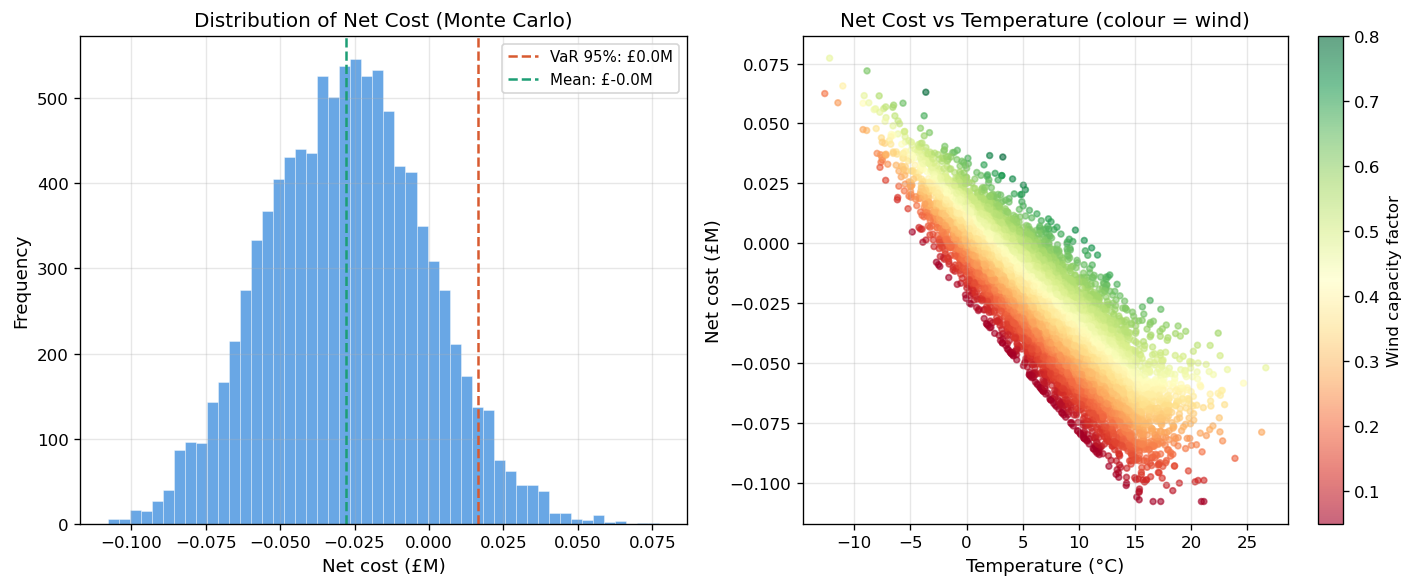

In [16]:
# Monte Carlo weather simulation
# Rather than just 5 point estimates, we simulate 10,000 weather outcomes and show the distribution of P&L.

np.random.seed(42)
N = 10000

# UK winter: mean 7°C, std 5°C
temps    = np.random.normal(loc=7.0,  scale=5.0,  size=N)
# Wind capacity factor: mean 35%, std 12%, clipped [5%, 80%]
wind_cfs = np.clip(np.random.normal(loc=0.35, scale=0.12, size=N), 0.05, 0.80)

mc_results = [scenario_pnl(t, w, portfolio) for t, w in zip(temps, wind_cfs)]
mc_df = pd.DataFrame(mc_results)

# Value at Risk (95th percentile worst case cost)
var_95 = np.percentile(mc_df['net_cost_gbp'], 95)
var_99 = np.percentile(mc_df['net_cost_gbp'], 99)
mean_cost = mc_df['net_cost_gbp'].mean()

print(f'Monte Carlo results (N={N} simulations)')
print(f'  Mean net cost  : £{mean_cost:,.0f}')
print(f'  VaR 95%        : £{var_95:,.0f}')
print(f'  VaR 99%        : £{var_99:,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: cost distribution
ax = axes[0]
ax.hist(mc_df['net_cost_gbp'] / 1e6, bins=50, color='#378ADD', alpha=0.75, edgecolor='white', linewidth=0.3)
ax.axvline(var_95 / 1e6, color='#D85A30', linewidth=1.5, linestyle='--', label=f'VaR 95%: £{var_95/1e6:.1f}M')
ax.axvline(mean_cost / 1e6, color='#1D9E75', linewidth=1.5, linestyle='--', label=f'Mean: £{mean_cost/1e6:.1f}M')
ax.set_xlabel('Net cost (£M)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution of Net Cost (Monte Carlo)', fontsize=12, fontweight='normal')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: scatter — temp vs P&L
ax2 = axes[1]
sc = ax2.scatter(mc_df['temp_c'], mc_df['net_cost_gbp'] / 1e6,
                 c=mc_df['wind_cf'], cmap='RdYlGn', s=12, alpha=0.6)
plt.colorbar(sc, ax=ax2, label='Wind capacity factor')
ax2.set_xlabel('Temperature (°C)', fontsize=11)
ax2.set_ylabel('Net cost (£M)', fontsize=11)
ax2.set_title('Net Cost vs Temperature (colour = wind)', fontsize=12, fontweight='normal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


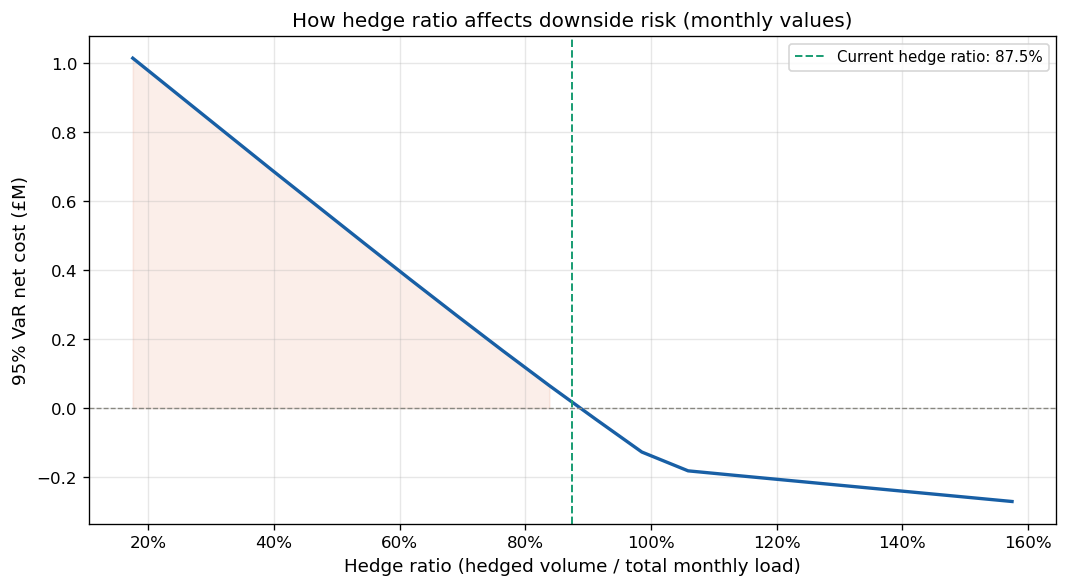

In [21]:
# Hedge sensitivity — how does hedge ratio affect VaR?

def portfolio_with_scale(scale: float):
    """Scale all portfolio volumes by a factor (simulates adding/removing hedges)."""
    return [
        CfDPosition(
            name=p.name, 
            strike_price=p.strike_price, 
            volume_mwh_per_month=p.volume_mwh_per_month * scale,  # CHANGED
            direction=p.direction,
            months_remaining=p.months_remaining  # Preserve original tenor
        )
        for p in portfolio
    ]

scales = np.linspace(0.2, 1.8, 20)
var95_by_scale = []
for s in scales:
    scaled_port = portfolio_with_scale(s)
    costs = [scenario_pnl(t, w, scaled_port)['net_cost_gbp']
             for t, w in zip(temps, wind_cfs)]
    var95_by_scale.append(np.percentile(costs, 95) / 1e6)


hedge_ratios = [sum(p.volume_mwh_per_month for p in portfolio_with_scale(s)) / BASE_LOAD_MWH_PER_MONTH
                for s in scales]

# Current hedge ratio (for reference line)
current_hedge_ratio = sum(p.volume_mwh_per_month for p in portfolio) / BASE_LOAD_MWH_PER_MONTH

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hedge_ratios, var95_by_scale, color='#185FA5', linewidth=2)
ax.axvline(current_hedge_ratio,
           color='#1D9E75', linewidth=1.2, linestyle='--', label=f'Current hedge ratio: {current_hedge_ratio:.1%}')
ax.axhline(0, color='#888780', linewidth=0.8, linestyle='--')
ax.fill_between(hedge_ratios, var95_by_scale, 0,
                where=[v > 0 for v in var95_by_scale], alpha=0.1, color='#D85A30')
ax.set_xlabel('Hedge ratio (hedged volume / total monthly load)', fontsize=11)
ax.set_ylabel('95% VaR net cost (£M)', fontsize=11)
ax.set_title('How hedge ratio affects downside risk (monthly values)', fontsize=12, fontweight='normal')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


I built a simplified weather risk model using Monte Carlo simulation to calculate VaR. In production,companies would use historical weather data, hourly resolution, and more price drivers, but my model demonstrates the core methodology.


## What this demonstrates
- Weather (temperature + wind) modelled as drivers of both demand and price
- Monte Carlo simulation over 10,000 weather scenarios → VaR output
- Hedge ratio sensitivity: quantifies the risk cost of being under/over-hedged
- All inputs are transparent and adjustable — unlike Excel

**Extension ideas for Clean Power 2030**: increase wind capacity, lower gas price scenarios, model negative price frequency increasing with more renewables.
